In [1]:
import warnings

warnings.simplefilter("ignore")
#from altaipony.lcio import from_mast
#from funcs.detrend import custom_detrending, estimate_detrended_noise
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.signal import find_peaks

from scipy.integrate import trapezoid
from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
from lightkurve import LightCurve
import lightkurve as lk

for att in ['axes.labelsize', 'axes.titlesize', 'legend.fontsize',
            'legend.fontsize', 'xtick.labelsize', 'ytick.labelsize']:
    plt.rcParams[att] = 15


In [2]:
search_result = search_lightcurve("AU Mic") 
lc2min = search_result[3].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
lc2_m = lc2.remove_nans()
lc2_m = lc2.remove_nans().normalize()

In [3]:
x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)


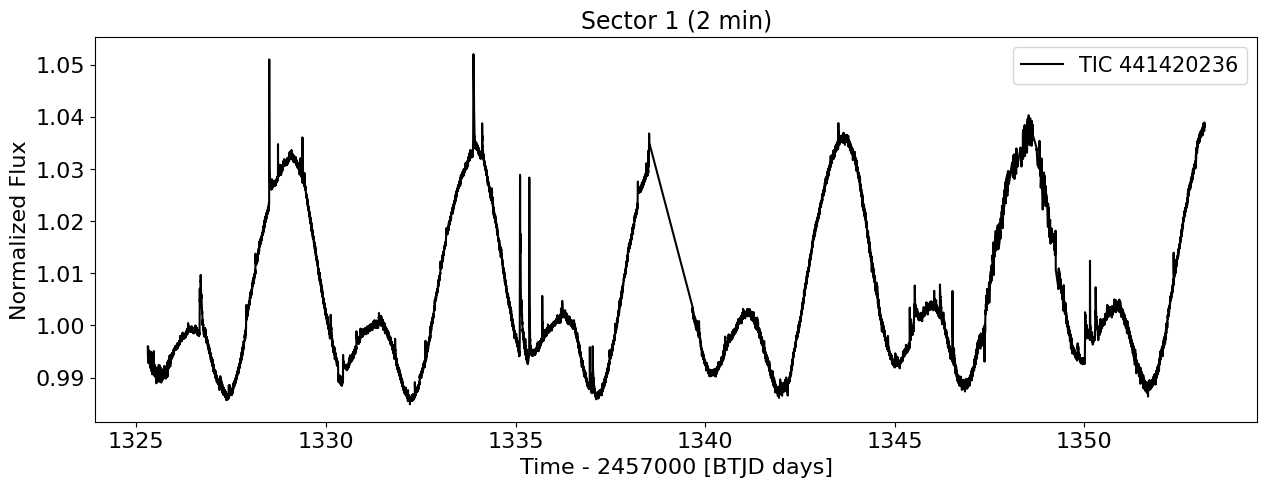

In [4]:

plt.rcParams['font.size'] = '16' 
fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(x2min,y2min,'k')
labels= ["TIC 441420236"]
ax.set_xlabel('Time - 2457000 [BTJD days]').set_fontsize(16)
ax.set_ylabel('Normalized Flux').set_fontsize(16)  
plt.title('Sector 1 (2 min)').set_fontsize(17)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.legend(labels) 
plt.show()


In [5]:
########### FLATTEN NOVO ##################

vetores = [
    [1326.6711, 1326.7794],
    [1327.8929, 1327.9763],
    [1328.4985, 1328.5822],
    [1328.4130, 1328,690],
    [1328.7326, 1328.7474],
    [1329.3756, 1329.4123],
    [1330.1210, 1330.1377],
    [1330.4496, 1330.5464],
    [1331.8210, 1331.8574],
    [1333.8797, 1333.9809],
    [1334.1134, 1334.1507],
    [1335.1052, 1335.2524],
    [1335.3517, 1335.4232],
    [1335.7022, 1335.7252],
    [1336.2287, 1336.2454],
    [1336.9519, 1336.9890],
    [1337.0179, 1337.0633],
    [1338.2201, 1338.2396],
    [1338.4973, 1338.5127],
    [1343.5045, 1343.5218],
    [1345.3914, 1345.4122],
    [1345.3918, 1345.4119],
    [1345.5044, 1345.5562],
    [1346.1841, 1346.2377],
    [1346.5162, 1346.5464],
    [1350.0068, 1350.0502],
    [1350.1441, 1350.3345],
    [1350.2795, 1350.3247],
    [1330.3039, 1330.4724],
    [1347.3173, 1347.3250],
    [1342.2240, 1342.2398],
    [1352.3514, 1352.3619],
    [1349.4516, 1349.4714],
    [1349.8142, 1349.8432],
    [1345.3926, 1345.4123],
    [1350.2720, 1350.3608],
    [1350.0112, 1350.4109],
    [1349.2727, 1349.3229],
]

vetor_true = [False]*len(x2min)



for j in range(len(x2min)):
    for i in range(len(vetores)):
        if (x2min[j]>=vetores[i][0]) and (x2min[j]<=vetores[i][1]):
            vetor_true[j] = True

mascara = np.array(vetor_true)

In [6]:
valores = [
    [1326.6645, 1326.8041],
    [1327.8932, 1327.9330],
    [1328.5027, 1328.7611],
    [1329.3765, 1329.4061],
    [1330.1159, 1330.1677],
    [1330.3149, 1330.4541],
    [1331.8200, 1331.8671],
    [1333.8795, 1333.9640],
    [1334.1140, 1334.1528],
    [1335.1052, 1335.2529],
    [1335.3517, 1335.4065],
    [1335.7001, 1335.7252],
    [1336.2287, 1336.2454],
    [1336.9519, 1336.9890],
    [1337.0179, 1337.0795],
    [1338.2217, 1338.3009],
    [1338.4965, 1338.5127],
    [1343.5045, 1343.5218],
    [1345.3914,1345.4589],
    [1347.2744, 1347.3911],
    [1347.2744, 1347.3911],
    [1346.1841, 1346.2377],
    [1346.5162, 1346.5464],
    [1349.4516, 1349.4714],
    [1349.8142, 1349.8432],
    [1350.0068, 1350.1396],
    [1350.1436, 1350.1649],
    [1350.2795, 1350.3477],
    [1352.3507, 1352.3648]
]

valores_true = [False]*len(x2min)


for j in range(len(x2min)):
    for i in range(len(valores)):
        if (x2min[j]>=valores[i][0]) and (x2min[j]<=valores[i][1]):
            valores_true[j] = True

mascara_1 = np.array(valores_true)


In [7]:
flcd = lc2_m.flatten(window_length=320, polyorder=4, return_trend=True, break_tolerance=100, niters=3, sigma=2.5, mask=mascara)
tempo_detrend = np.ascontiguousarray(flcd[1].time.value, dtype=np.float64) 
fluxo_detrend = np.ascontiguousarray(flcd[1].flux, dtype=np.float64)

In [8]:
#Recortando e ajeitando ainda mais a normalização 
xdefinitivo2 = []
ydefinitivo2 = []
for j in range(len(y2min)):
    if 1328.38895 < x2min[j] < 1328.79932:
        xdefinitivo2.append(x2min[j])
        ydefinitivo2.append(y2min[j])

xdefinitivo2 = np.array(xdefinitivo2)
ydefinitivo2 = np.array(ydefinitivo2)

vetores1 = [
    [1328.4985, 1328.666],
    [1328.729,2328.784]
]
vetor_true1 = [False]*len(xdefinitivo2)

for j in range(len(xdefinitivo2)):
    for i in range(len(vetores1)):
        if (xdefinitivo2[j]>=vetores1[i][0]) and (xdefinitivo2[j]<=vetores1[i][1]):
            vetor_true1[j] = True

mascara1 = np.array(vetor_true1)

lc =  LightCurve(time=xdefinitivo2, flux=ydefinitivo2)
flcd2 = lc.flatten(window_length=30, polyorder=1, return_trend=True, break_tolerance=10, niters=2, sigma=2.5, mask=mascara1)


detrended_lc = flcd2[1]

tempo_detrend1 = np.ascontiguousarray(detrended_lc.time.value, dtype=np.float64)
fluxo_detrend1 = np.ascontiguousarray(detrended_lc.flux, dtype=np.float64)

#################################################################################################################
xdefinitivo3 = []
ydefinitivo3 = []
for j in range(len(y2min)):
    if 1338.146329 < x2min[j] < 1338.322494:
        xdefinitivo3.append(x2min[j])
        ydefinitivo3.append(y2min[j])

xdefinitivo3 = np.array(xdefinitivo3)
ydefinitivo3 = np.array(ydefinitivo3)

vetores2 = [
    [1338.2152,1338.3017]
]
vetor_true2 = [False]*len(xdefinitivo3)

for j in range(len(xdefinitivo3)):
    for i in range(len(vetores2)):
        if (xdefinitivo3[j]>=vetores2[i][0]) and (xdefinitivo3[j]<=vetores2[i][1]):
            vetor_true2[j] = True

mascara3 = np.array(vetor_true2)

lc2 =  LightCurve(time=xdefinitivo3, flux=ydefinitivo3)
flcd3 = lc2.flatten(window_length=35, polyorder=1, return_trend=True, break_tolerance=10, niters=3, sigma=2.5, mask=mascara3)

detrended_lc = flcd3[1]

tempo_detrend3 = np.ascontiguousarray(detrended_lc.time.value, dtype=np.float64)
fluxo_detrend3 = np.ascontiguousarray(detrended_lc.flux, dtype=np.float64)

##########################################################################################################
xdefinitivo4 = []
ydefinitivo4 = []
for j in range(len(y2min)):
    if 1347.9821 < x2min[j] < 1349.4213:
        xdefinitivo4.append(x2min[j])
        ydefinitivo4.append(y2min[j])

xdefinitivo4 = np.array(xdefinitivo4)
ydefinitivo4 = np.array(ydefinitivo4)



lc4 =  LightCurve(time=xdefinitivo4, flux=ydefinitivo4)
flcd4 = lc4.flatten(window_length=250, polyorder=4, return_trend=True, break_tolerance=100, niters=3, sigma=2.5, mask=None)

detrended_lc = flcd4[1]

tempo_detrend4 = np.ascontiguousarray(detrended_lc.time.value, dtype=np.float64)
fluxo_detrend4 = np.ascontiguousarray(detrended_lc.flux, dtype=np.float64)

##############################################################################################################################################################

xdefinitivo5 = []
ydefinitivo5 = []
for j in range(len(y2min)):
    if 1345.3085 < x2min[j] < 1345.6397:
        xdefinitivo5.append(x2min[j])
        ydefinitivo5.append(y2min[j])


xdefinitivo5 = np.array(xdefinitivo5)
ydefinitivo5 = np.array(ydefinitivo5)

vetores3 = [
    [1345.3886,1345.4579],
    [1345.4992,1345.6308]
]
vetor_true3 = [False]*len(xdefinitivo5)

for j in range(len(xdefinitivo5)):
    for i in range(len(vetores3)):
        if (xdefinitivo5[j]>=vetores3[i][0]) and (xdefinitivo5[j]<=vetores3[i][1]):
            vetor_true3[j] = True

mascara5 = np.array(vetor_true3)


lc5 =  LightCurve(time=xdefinitivo5, flux=ydefinitivo5)
flcd5 = lc5.flatten(window_length=30, polyorder=1, return_trend=True, break_tolerance=6, niters=3, sigma=2.5, mask=mascara5)

detrended_lc = flcd5[1]

tempo_detrend5 = np.ascontiguousarray(detrended_lc.time.value, dtype=np.float64)
fluxo_detrend5 = np.ascontiguousarray(detrended_lc.flux, dtype=np.float64)





#########################################################################################################################################################################
########### O FOR PARA O CORTE DOS VALORES QUE ESTÃO COM NORMALIZAÇÃO RUIM E ADICIONAR NA NORMALIZAÇÃO MELHOR############################
count = 0
count1 = 0
count2 = 0
count3 = 0

for j in range(len(tempo_detrend)):
    if tempo_detrend[j]>=1328.38895 and  tempo_detrend[j]<=1328.79932:
       fluxo_detrend[j]= fluxo_detrend1[count]
       tempo_detrend[j]= tempo_detrend1[count]
       count = count + 1
    if tempo_detrend[j]>=1338.146329 and  tempo_detrend[j]<=1338.322494:
       fluxo_detrend[j]= fluxo_detrend3[count1]
       tempo_detrend[j]= tempo_detrend3[count1]
       count1 = count1 + 1
    if tempo_detrend[j]>= 1347.9821 and  tempo_detrend[j]<=1349.4213:
       fluxo_detrend[j]= fluxo_detrend4[count2]
       tempo_detrend[j]= tempo_detrend4[count2]
       count2 = count2 + 1
    if tempo_detrend[j]>= 1345.3085 and  tempo_detrend[j]<=1345.6397:
       fluxo_detrend[j]= fluxo_detrend5[count3]
       tempo_detrend[j]= tempo_detrend5[count3]
       count3 = count3 + 1
   

In [9]:
x_detrend = []
y_detrend = []
for j in range(len(mascara_1)):
    if  mascara_1[j] == False:
        y_detrend.append(fluxo_detrend[j])
        x_detrend.append(tempo_detrend[j])
mascara2 = [False]*len(mascara_1)

In [10]:

#Calculando a média simples dos dados 

y_mean = np.mean(y_detrend)
#Media para todos os pontos do eixo x, para apresentar no grafico 
#y_mean2 = [y_mean for i in range(len(y))]
y_mean2 = [y_mean]*len(y_detrend)
#Calculo do desvio padrao dos dados
desvio = (np.std(y_detrend))
#print(y_mean)
#Media mais desvio padrao
med_desv = y_mean2+desvio

#Corte nos valores de média+ 2*sigma

med_desv2 = y_mean + (2*desvio)
med_desv3 = y_mean - (2*desvio)
xdefinitivo = []
ydefinitivo = []
for j in range(len(y_detrend)):
    if y_detrend[j] < med_desv2 and y_detrend[j]>med_desv3:
        ydefinitivo.append(y_detrend[j])
        xdefinitivo.append(x_detrend[j])
xdefinitivo = np.array(xdefinitivo)
ydefinitivo = np.array(ydefinitivo)

#Calculo novo da média e do desvio padrão do ruido 
y_m = np.mean(ydefinitivo)
y_m2 = [y_m]*len(ydefinitivo)
desvio2 = (np.std(ydefinitivo))
med = y_m2 + desvio2
med2 = y_m +3*desvio2
print(desvio2)

0.013050898537369711


In [11]:
peaks,_= find_peaks(fluxo_detrend, height=med2)

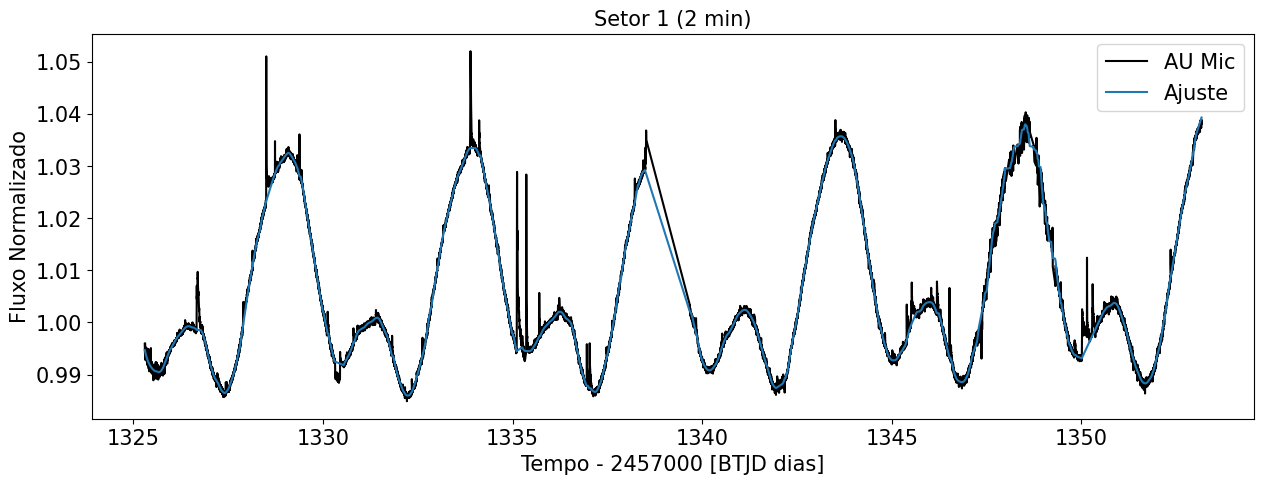

In [12]:
fig,ax = plt.subplots(1,1,figsize=(15,5))
#Plot do detrend
ax.plot(x2min, y2min, label = 'AU Mic', color = 'black')
ax.plot(tempo_detrend, fluxo_detrend, label = 'Ajuste')
#Legenda
legend = ax.legend(loc='upper right')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.set_title('Setor 1 (2 min)')
ax.legend()
plt.show()


In [62]:
# Valores de início e término da flare (substitua pelos valores desejados)
start_input = 1334.1140
stop_input = 1334.1520

def ener_flare(start, stop, tempo_detrend, fluxo_detrend):
    flux_flare = []
    tempo_flare = []
    for i in range(len(tempo_detrend)):
        if tempo_detrend[i] >= start and tempo_detrend[i] <= stop:
            flux_flare.append(fluxo_detrend[i])
            tempo_flare.append(tempo_detrend[i])

    flux_flare = np.array(flux_flare)
    tempo_flare = np.array(tempo_flare)
    
    return flux_flare, tempo_flare
#fig,ax = plt.subplots(1,1,figsize=(7,5))
#print(flux_flare)
#print(tempo_flare)
# Chamada da função ener_flare com os dados de exemplo
flux_flare, tempo_flare = ener_flare(start_input, stop_input, tempo_detrend, fluxo_detrend)
# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flare, flux_flare, 'r')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()

In [47]:
##### Alguns dados básicos##################
#fl129=pd.read_csv('flares_setor27.csv') #lendo os flares 
tess_f = pd.read_csv('tess_functionx1.csv') #lendo os arquivos da função de resposta
tf = pd.DataFrame(tess_f)
#df = pd.DataFrame(fl129)

nm= np.array(tf["nm"]) # comprimento de onda em nm
ry= np.array(tf["ry"]) # tess function response

In [48]:
#Energia da flare
from PyAstronomy.pyasl import planck

#Mudança nm para cm e metro 
nm_metros = nm*(1e-9) #de nm para metros 
nm_cm = nm*(1e-7) #de nm para cm 

#Constantes importantes 
Teff= 3700# temperatura efetiva au mic
Tflare=10000# temperatura flare
raio=0.75*6.957e+10 # raio solar cm
sb1=5.67051e-5 #ergs cm-2*s-1*K-4

###########################
#Calculo da função de Planck
# Essa função (Bs=planck(Teff,lam=nm_metros)) da em [W/(m**2 m)] então
Bs=planck(Teff,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)
Bf=planck(Tflare,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)
##### Alguns dados básicos##################


5.406460217834754e+33


<IPython.core.display.Javascript object>


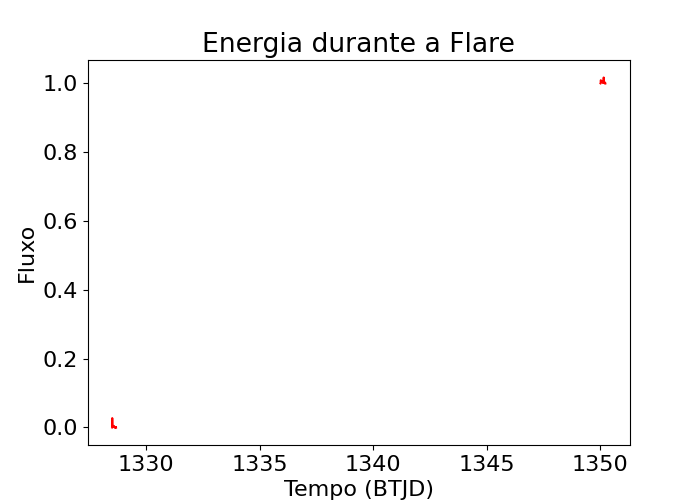

In [129]:
#%matplotlib notebook
flux_flare1 = np.array(flux_flare)
tempo_flare1 = np.array(tempo_flare) 

# Fluxo relativo da estrela (valor mínimo de fluxo na região da flare)
f_rel_estrela = np.min(flux_flare1)

# Calcular a amplitude da flare (diferença entre o fluxo máximo da flare e o fluxo relativo da estrela)
amplitude_flare =  flux_flare1 - 1


# Integral
Aflare = amplitude_flare*np.pi*(raio**2) #(cm^2)

Aflare1 = simps(ry*Bs,nm_cm)/simps(ry*Bf,nm_cm)

# Área total da flare
Atotal = Aflare*Aflare1 #cm^2

# Luminosidade da flare
L = sb1*(Tflare**4)*Atotal #erg/s

# Energia bolométrica do flare

E1 = simps(L,tempo_flare1*86400) #erg



print(E1)
fig,ax = plt.subplots(1,1,figsize=(7,5))
# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flare1, amplitude_flare, 'r')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()

In [111]:
##### Alguns dados básicos##################
fl129=pd.read_csv('flares_setor1_new.csv') #lendo os flares 
df = pd.DataFrame(fl129)


In [112]:
######################## PARAMETROS DAS EXPLOSÕES #######################################
#Duração da flare

def dur(start,stop):
    dur1=abs(stop[0]-start[0])*1440
    #print("%.5f",dur1)
    #return dur1
    print("%.5f" %dur1)
    #dur1=abs(stop[1]-start[1])
    #print("diferença:", "%.5f" %dur1, "min", "inicio:", "%.5f" %start[1],"fim:", "%.5f" %stop[1], "")
    #print("inicio:", "%.5f" %start,"fim:", "%.5f" %stop, "min")
    
#Tempo de subida e descida
def subdes(start,stop):
    maximo = start[1]
    maximo_t = 0.0
    for i in range(len(tempo_detrend)):
        if tempo_detrend[i]>start[0] and tempo_detrend[i]<stop[0]:
            if fluxo_detrend[i]> maximo:
                maximo = fluxo_detrend[i]
                maximo_t = tempo_detrend[i]
    rise=(maximo_t-start[0])*1440
    decay=(stop[0]-maximo_t)*1440
    #print("Subida:", "%.5f" %rise, "min", "Descida:", "%.5f" %decay, "min")
    #print("%.5f" %decay)
    print("%.5f" %rise)
    #print("maximo", maximo)
    #print("inicio, fim", start[0],stop[0])
    #print("duração", (stop[0]-start[0])*1440)
    #print("duração2", (rise+decay))
def ampl(start,stop):
    maximo = start[1]
    minimo = start[1]
    #med = np.mean(flux)
    for i in range(len(tempo_detrend)):
        if tempo_detrend[i]>start[0] and tempo_detrend[i]<stop[0]:
            if fluxo_detrend[i]> maximo:
                maximo = fluxo_detrend[i]
            if fluxo_detrend[i] < minimo:
                minimo = fluxo_detrend[i]  
    amplitude = maximo-minimo 
    print( "%.8f" %amplitude)

def flare(start,stop):
    flux_flare = []
    tempo_flare = []
    for i in range(len(tempo_detrend)):
        if tempo_detrend[i]>start[0] and tempo_detrend[i]<stop[0]:
            flux_flare.append(fluxo_detrend[i])
            tempo_flare.append(tempo_detrend[i])
            
    flux_flare = np.array(flux_flare)
    tempo_flare = np.array(tempo_flare)
    # Fluxo relativo da estrela (valor mínimo de fluxo na região da flare)
    f_rel_estrela = np.min(flux_flare)

    # Calcular a amplitude da flare (diferença entre o fluxo máximo da flare e o fluxo relativo da estrela)
    amplitude_flare =  flux_flare - 1
    # Integral
    Aflare = amplitude_flare*np.pi*(raio**2) #(cm^2)

    Aflare1 = simps(ry*Bs,nm_cm)/simps(ry*Bf,nm_cm)

    # Área total da flare
    Atotal = Aflare*Aflare1 #cm^2

    # Luminosidade da flare
    L = sb1*(Tflare**4)*Atotal #erg/s

    # Energia bolométrica do flare

    E1 = simps(L,tempo_flare*86400) #erg
    print('%.5e' %E1)


In [115]:
#Flares selecionadas
flare1_i = df.iloc[0,0],df.iloc[0,1]
flare1_f = df.iloc[0,2],df.iloc[0,3]
##########################
flare2_i = df.iloc[1,0],df.iloc[1,1]
flare2_f = df.iloc[1,2],df.iloc[1,3]
##########################
flare3_i = df.iloc[2,0],df.iloc[2,1]
flare3_f = df.iloc[2,2],df.iloc[2,3]
##########################
flare4_i = df.iloc[3,0],df.iloc[3,1]
flare4_f = df.iloc[3,2],df.iloc[3,3]
##########################
flare5_i = df.iloc[4,0],df.iloc[4,1]
flare5_f = df.iloc[4,2],df.iloc[4,3]
##########################
flare6_i = df.iloc[5,0],df.iloc[5,1]
flare6_f = df.iloc[5,2],df.iloc[5,3]
##########################
flare7_i = df.iloc[6,0],df.iloc[6,1]
flare7_f = df.iloc[6,2],df.iloc[6,3]
##########################
flare8_i = df.iloc[7,0],df.iloc[7,1]
flare8_f = df.iloc[7,2],df.iloc[7,3]
##########################
flare9_i = df.iloc[8,0],df.iloc[8,1]
flare9_f = df.iloc[8,2],df.iloc[8,3]
##########################
flare10_i = df.iloc[9,0],df.iloc[9,1]
flare10_f = df.iloc[9,2],df.iloc[9,3]
##########################
flare11_i = df.iloc[10,0],df.iloc[10,1]
flare11_f = df.iloc[10,2],df.iloc[10,3]
##########################
flare12_i = df.iloc[11,0],df.iloc[11,1]
flare12_f = df.iloc[11,2],df.iloc[11,3]
##########################
flare13_i = df.iloc[12,0],df.iloc[12,1]
flare13_f = df.iloc[12,2],df.iloc[12,3]
##########################
flare14_i = df.iloc[13,0],df.iloc[13,1]
flare14_f = df.iloc[13,2],df.iloc[13,3]
##########################
flare15_i = df.iloc[14,0],df.iloc[14,1]
flare15_f = df.iloc[14,2],df.iloc[14,3]
##########################
flare16_i = df.iloc[15,0],df.iloc[15,1]
flare16_f = df.iloc[15,2],df.iloc[15,3]
##########################
flare17_i = df.iloc[16,0],df.iloc[16,1]
flare17_f = df.iloc[16,2],df.iloc[16,3]
##########################
flare18_i = df.iloc[17,0],df.iloc[17,1]
flare18_f = df.iloc[17,2],df.iloc[17,3]
##########################
flare19_i = df.iloc[18,0],df.iloc[18,1]
flare19_f = df.iloc[18,2],df.iloc[18,3]
##########################
flare20_i = df.iloc[19,0],df.iloc[19,1]
flare20_f = df.iloc[19,2],df.iloc[19,3]
##########################
flare21_i = df.iloc[20,0],df.iloc[20,1]
flare21_f = df.iloc[20,2],df.iloc[20,3]
##########################
flare22_i = df.iloc[21,0],df.iloc[21,1]
flare22_f = df.iloc[21,2],df.iloc[21,3]
##########################
flare23_i = df.iloc[22,0],df.iloc[22,1]
flare23_f = df.iloc[22,2],df.iloc[22,3]
##########################
flare24_i = df.iloc[23,0],df.iloc[23,1]
flare24_f = df.iloc[23,2],df.iloc[23,3]
##########################
flare25_i = df.iloc[24,0],df.iloc[24,1]
flare25_f = df.iloc[24,2],df.iloc[24,3]
##########################
flare26_i = df.iloc[25,0],df.iloc[25,1]
flare26_f = df.iloc[25,2],df.iloc[25,3]
##########################
flare27_i = df.iloc[26,0],df.iloc[26,1]
flare27_f = df.iloc[26,2],df.iloc[26,3]
##########################
flare28_i = df.iloc[27,0],df.iloc[27,1]
flare28_f = df.iloc[27,2],df.iloc[27,3]
##########################
flare29_i = df.iloc[28,0],df.iloc[28,1]
flare29_f = df.iloc[28,2],df.iloc[28,3]
##########################
flare30_i = df.iloc[29,0],df.iloc[29,1]
flare30_f = df.iloc[29,2],df.iloc[29,3]
##########################
flare31_i = df.iloc[30,0],df.iloc[30,1]
flare31_f = df.iloc[30,2],df.iloc[30,3]
##########################
flare32_i = df.iloc[31,0],df.iloc[31,1]
flare32_f = df.iloc[31,2],df.iloc[31,3]
##########################
flare33_i = df.iloc[32,0],df.iloc[32,1]
flare33_f = df.iloc[32,2],df.iloc[32,3]
print(flare3_i,flare3_f)

(1327.893, 0.99972) (1328.024, 0.99918)


In [114]:
dur(flare1_i,flare1_f)
dur(flare2_i,flare2_f)
dur(flare3_i,flare3_f)
dur(flare4_i,flare4_f)
dur(flare5_i,flare5_f)
dur(flare6_i,flare6_f)
dur(flare7_i,flare7_f)
dur(flare8_i,flare8_f)
dur(flare9_i,flare9_f)
dur(flare10_i,flare10_f)
dur(flare11_i,flare11_f)
dur(flare12_i,flare12_f)
dur(flare13_i,flare13_f)
dur(flare14_i,flare14_f)
dur(flare15_i,flare15_f)
dur(flare16_i,flare16_f)
dur(flare17_i,flare17_f)
dur(flare18_i,flare18_f)
dur(flare19_i,flare19_f)
dur(flare20_i,flare20_f)
dur(flare21_i,flare21_f)
dur(flare22_i,flare22_f)
dur(flare23_i,flare23_f)
dur(flare24_i,flare24_f)
dur(flare25_i,flare25_f)
dur(flare26_i,flare26_f)
dur(flare27_i,flare27_f)
dur(flare28_i,flare28_f)
dur(flare29_i,flare29_f)
dur(flare30_i,flare30_f)
dur(flare31_i,flare31_f)
dur(flare32_i,flare32_f)
dur(flare33_i,flare33_f)

167.61600
66.24000
188.64000
43.20000
244.08000
42.62400
26.49600
70.56000
42.91200
31.10400
161.56800
55.87200
204.19200
84.96000
36.14400
61.92000
92.73600
118.94400
27.50400
47.52000
32.83200
42.48000
31.68000
58.60800
179.28000
45.36000
77.18400
15.69600
42.33600
79.05600
307.00800
120.96000
20.44800


In [66]:
subdes(flare1_i,flare1_f)
subdes(flare2_i,flare2_f)
subdes(flare3_i,flare3_f)
subdes(flare4_i,flare4_f)
subdes(flare5_i,flare5_f)
subdes(flare6_i,flare6_f)
subdes(flare7_i,flare7_f)
subdes(flare8_i,flare8_f)
subdes(flare9_i,flare9_f)
subdes(flare10_i,flare10_f)
subdes(flare11_i,flare11_f)
subdes(flare12_i,flare12_f)
subdes(flare13_i,flare13_f)
subdes(flare14_i,flare14_f)
subdes(flare15_i,flare15_f)
subdes(flare16_i,flare16_f)
subdes(flare17_i,flare17_f)
subdes(flare18_i,flare18_f)
subdes(flare19_i,flare19_f)
subdes(flare20_i,flare20_f)
subdes(flare21_i,flare21_f)
subdes(flare22_i,flare22_f)
subdes(flare23_i,flare23_f)
subdes(flare24_i,flare24_f)
subdes(flare25_i,flare25_f)
subdes(flare26_i,flare26_f)
subdes(flare27_i,flare27_f)
subdes(flare28_i,flare28_f)
subdes(flare29_i,flare29_f)
subdes(flare30_i,flare30_f)
subdes(flare31_i,flare31_f)
subdes(flare32_i,flare32_f)
subdes(flare33_i,flare33_f)

47.13593
8.49422
8.09147
6.41035
6.56856
5.84513
6.24493
12.24183
5.19127
6.22127
15.48872
7.80487
18.45925
10.16674
5.79230
17.67348
26.16822
12.85101
7.40668
6.33005
17.07412
11.98105
4.02109
16.59569
31.29554
12.40976
8.49926
4.71936
5.10895
13.86999
201.63040
32.29523
2.30551


In [67]:
ampl(flare1_i,flare1_f)
ampl(flare2_i,flare2_f)
ampl(flare3_i,flare3_f)
ampl(flare4_i,flare4_f)
ampl(flare5_i,flare5_f)
ampl(flare6_i,flare6_f)
ampl(flare7_i,flare7_f)
ampl(flare8_i,flare8_f)
ampl(flare9_i,flare9_f)
ampl(flare10_i,flare10_f)
ampl(flare11_i,flare11_f)
ampl(flare12_i,flare12_f)
ampl(flare13_i,flare13_f)
ampl(flare14_i,flare14_f)
ampl(flare15_i,flare15_f)
ampl(flare16_i,flare16_f)
ampl(flare17_i,flare17_f)
ampl(flare18_i,flare18_f)
ampl(flare19_i,flare19_f)
ampl(flare20_i,flare20_f)
ampl(flare21_i,flare21_f)
ampl(flare22_i,flare22_f)
ampl(flare23_i,flare23_f)
ampl(flare24_i,flare24_f)
ampl(flare25_i,flare25_f)
ampl(flare26_i,flare26_f)
ampl(flare27_i,flare27_f)
ampl(flare28_i,flare28_f)
ampl(flare29_i,flare29_f)
ampl(flare30_i,flare30_f)
ampl(flare31_i,flare31_f)
ampl(flare32_i,flare32_f)
ampl(flare33_i,flare33_f)

0.01270007
0.00205148
0.00451468
0.00347149
0.02838553
0.00817390
0.00343014
0.00476765
0.00402812
0.00289697
0.01956785
0.00794235
0.03466440
0.03446227
0.00976537
0.01067790
0.00947549
0.00543873
0.00254425
0.00395097
0.00300149
0.00267708
0.00869493
0.00539639
0.00962784
0.00456230
0.00781363
0.00357151
0.01519333
0.00456080
0.01895033
0.01152105
0.00673791


In [68]:
flare(flare1_i,flare1_f) #Complexa
flare(flare2_i,flare2_f)
flare(flare3_i,flare3_f)
flare(flare4_i,flare4_f)
flare(flare5_i,flare5_f)
flare(flare6_i,flare6_f)
flare(flare7_i,flare7_f)
flare(flare8_i,flare8_f)
flare(flare9_i,flare9_f)
flare(flare10_i,flare10_f)
flare(flare11_i,flare11_f) #Complexa
flare(flare12_i,flare12_f)
flare(flare13_i,flare13_f)
flare(flare14_i,flare14_f)
flare(flare15_i,flare15_f)
flare(flare16_i,flare16_f) #Complexa
flare(flare17_i,flare17_f) #Complexa
flare(flare18_i,flare18_f)
flare(flare19_i,flare19_f) #Complexa
flare(flare20_i,flare20_f)
flare(flare21_i,flare21_f)
flare(flare22_i,flare22_f)
flare(flare23_i,flare23_f)
flare(flare24_i,flare24_f)
flare(flare25_i,flare25_f)
flare(flare26_i,flare26_f)
flare(flare27_i,flare27_f)
flare(flare28_i,flare28_f)
flare(flare29_i,flare29_f)
flare(flare30_i,flare30_f)
flare(flare31_i,flare31_f)
flare(flare32_i,flare32_f)
flare(flare33_i,flare33_f)

7.10980e+33
4.98055e+32
1.65958e+33
2.82766e+32
5.40646e+33
9.17208e+32
1.79619e+32
8.08547e+32
5.38830e+32
1.58828e+32
6.12226e+33
1.13801e+33
1.50634e+34
3.83622e+33
8.80289e+32
1.14531e+33
2.36851e+33
1.53012e+33
1.77897e+32
4.49280e+32
3.69686e+32
3.87662e+32
5.95937e+32
8.11632e+32
3.88814e+33
3.82608e+32
1.68429e+33
1.07272e+32
1.33965e+33
7.54865e+32
1.09772e+34
3.57072e+33
2.83466e+32


In [61]:
'''
%matplotlib notebook
plt.rcParams['font.size'] = 16
fig,ax = plt.subplots(1,1,figsize=(10,5))

#plt.plot( fluxo_detrend,'black')
data_line2 = ax.plot(tempo_detrend,fluxo_detrend, marker='.', color='black')
#data_line = ax.plot(fluxo_detrend, label='Dados', marker='.', color='black')
#plt.plot(tempo_detrend[picos], fluxo_detrend[picos], 'ro', label='Picos')
#plt.plot(peaks, fluxo_detrend[peaks],"x")
#Plot da linha pontilhada media e desvio
mean_line = ax.plot(xdefinitivo,med, label='Média+$\sigma$', linestyle='--', color = 'red')
data_line2 = ax.plot(xdefinitivo,y_m2, label='média',linestyle='--', color='blue')

#Legenda
#legend = ax.legend(loc='upper right')
#ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
#ax.legend()
plt.show()
'''

'\n%matplotlib notebook\nplt.rcParams[\'font.size\'] = 16\nfig,ax = plt.subplots(1,1,figsize=(10,5))\n\n#plt.plot( fluxo_detrend,\'black\')\ndata_line2 = ax.plot(tempo_detrend,fluxo_detrend, marker=\'.\', color=\'black\')\n#data_line = ax.plot(fluxo_detrend, label=\'Dados\', marker=\'.\', color=\'black\')\n#plt.plot(tempo_detrend[picos], fluxo_detrend[picos], \'ro\', label=\'Picos\')\n#plt.plot(peaks, fluxo_detrend[peaks],"x")\n#Plot da linha pontilhada media e desvio\nmean_line = ax.plot(xdefinitivo,med, label=\'Média+$\\sigma$\', linestyle=\'--\', color = \'red\')\ndata_line2 = ax.plot(xdefinitivo,y_m2, label=\'média\',linestyle=\'--\', color=\'blue\')\n\n#Legenda\n#legend = ax.legend(loc=\'upper right\')\n#ax.set(xlabel = \'Tempo - 2457000 [BTJD dias]\', ylabel = \'Fluxo Normalizado\',rasterized=True)\n#ax.legend()\nplt.show()\n'